In [1]:
#Download and inspect the dataset
import pandas as pd
import numpy as np
df = pd.read_csv("C:/Users/HP/Downloads/Food_Delivery_Time_Prediction (1).csv")

df.head()

,Order_ID,Order_Date,Order_Hour,Day_of_Week,Is_Weekend,Is_Festival,Weather,Pickup_Zone,Dropoff_Zone,Vehicle_Type,...,Order_Items,Restaurant_Load,Preparation_Time_Min,Road_Distance_km,Delivery_Distance_Category,Traffic_Level,Number_of_Signals,Average_Speed_kmph,Delivery_Priority,Time_taken_min
0,ORD000001,2025-10-28,8,Tuesday,0,0,Clear,CBD,Commercial,Scooter,...,1,Medium,23,30.55,Long,Moderate,15,28.7,Normal,91
1,ORD000002,2025-09-26,12,Friday,0,0,Rain,CBD,CBD,Scooter,...,3,Medium,11,2.25,Short,Moderate,17,23.3,Normal,21
2,ORD000003,2025-01-26,18,Sunday,1,0,Clear,Residential,Residential,Scooter,...,1,Low,31,10.15,Long,Moderate,8,28.9,Normal,52
3,ORD000004,2025-11-19,12,Wednesday,0,0,Cloudy,Residential,Industrial,Bike,...,3,Medium,19,26.33,Long,Low,9,41.4,Normal,59
4,ORD000005,2025-08-04,18,Monday,0,0,Rain,Industrial,Residential,Bike,...,1,Medium,7,30.48,Long,Moderate,8,31.7,Normal,75


In [2]:
#Understand your dataset before modelling
df.shape

(50000, 24)

In [3]:
df.columns

Index(['Order_ID', 'Order_Date', 'Order_Hour', 'Day_of_Week', 'Is_Weekend',
       'Is_Festival', 'Weather', 'Pickup_Zone', 'Dropoff_Zone', 'Vehicle_Type',
       'Rider_Experience_Years', 'Rider_Rating', 'Restaurant_Rating',
       'Cuisine_Type', 'Order_Items', 'Restaurant_Load',
       'Preparation_Time_Min', 'Road_Distance_km',
       'Delivery_Distance_Category', 'Traffic_Level', 'Number_of_Signals',
       'Average_Speed_kmph', 'Delivery_Priority', 'Time_taken_min'],
      dtype='object')

In [4]:
#Basic Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    50000 non-null  object 
 1   Order_Date                  50000 non-null  object 
 2   Order_Hour                  50000 non-null  int64  
 3   Day_of_Week                 50000 non-null  object 
 4   Is_Weekend                  50000 non-null  int64  
 5   Is_Festival                 50000 non-null  int64  
 6   Weather                     50000 non-null  object 
 7   Pickup_Zone                 50000 non-null  object 
 8   Dropoff_Zone                50000 non-null  object 
 9   Vehicle_Type                50000 non-null  object 
 10  Rider_Experience_Years      50000 non-null  float64
 11  Rider_Rating                50000 non-null  float64
 12  Restaurant_Rating           50000 non-null  float64
 13  Cuisine_Type                500

In [5]:
df.describe()

,Order_Hour,Is_Weekend,Is_Festival,Rider_Experience_Years,Rider_Rating,Restaurant_Rating,Order_Items,Preparation_Time_Min,Road_Distance_km,Number_of_Signals,Average_Speed_kmph,Time_taken_min
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000
mean,13.847700,0.283600,0.049100,4.439744,3.951646,4.175368,2.652740,24.03118,26.201744,9.728920,31.759634,83.868980
std,5.525291,0.450749,0.216079,2.927752,0.294960,0.356201,1.590359,8.34877,12.620079,4.330849,9.510842,35.426899
min,0.000000,0.000000,0.000000,0.100000,3.200000,3.300000,1.000000,5.00000,0.080000,2.000000,8.000000,10.000000
25%,10.000000,0.000000,0.000000,2.200000,3.700000,3.900000,1.000000,18.00000,16.330000,6.000000,25.300000,58.000000
50%,14.000000,0.000000,0.000000,3.800000,3.900000,4.200000,2.000000,24.00000,25.620000,9.000000,33.100000,78.000000
75%,19.000000,1.000000,0.000000,5.900000,4.100000,4.400000,4.000000,30.00000,35.480000,14.000000,39.600000,102.000000
max,23.000000,1.000000,1.000000,15.000000,5.000000,5.000000,7.000000,51.00000,70.820000,18.000000,48.300000,180.000000


In [6]:
#Checking missing values
df.isnull().sum()

Order_ID                      0
Order_Date                    0
Order_Hour                    0
Day_of_Week                   0
Is_Weekend                    0
Is_Festival                   0
Weather                       0
Pickup_Zone                   0
Dropoff_Zone                  0
Vehicle_Type                  0
Rider_Experience_Years        0
Rider_Rating                  0
Restaurant_Rating             0
Cuisine_Type                  0
Order_Items                   0
Restaurant_Load               0
Preparation_Time_Min          0
Road_Distance_km              0
Delivery_Distance_Category    0
Traffic_Level                 0
Number_of_Signals             0
Average_Speed_kmph            0
Delivery_Priority             0
Time_taken_min                0
dtype: int64

In [7]:
#Checking Duplicate
df.duplicated().sum()

0

In [8]:
#Check Categorical values
categorical_columns = df.select_dtypes(include="object").columns
categorical_columns

Index(['Order_ID', 'Order_Date', 'Day_of_Week', 'Weather', 'Pickup_Zone',
       'Dropoff_Zone', 'Vehicle_Type', 'Cuisine_Type', 'Restaurant_Load',
       'Delivery_Distance_Category', 'Traffic_Level', 'Delivery_Priority'],
      dtype='object')

In [9]:
for col in categorical_columns:
    print("\n", col)
    print(df[col].nunique())
    print(df[col].unique()[:10])


 Order_ID
50000
['ORD000001' 'ORD000002' 'ORD000003' 'ORD000004' 'ORD000005' 'ORD000006'
 'ORD000007' 'ORD000008' 'ORD000009' 'ORD000010']

 Order_Date
365
['2025-10-28' '2025-09-26' '2025-01-26' '2025-11-19' '2025-08-04'
 '2025-01-22' '2025-08-19' '2025-04-11' '2025-01-23' '2025-09-19']

 Day_of_Week
7
['Tuesday' 'Friday' 'Sunday' 'Wednesday' 'Monday' 'Thursday' 'Saturday']

 Weather
5
['Clear' 'Rain' 'Cloudy' 'Storm' 'Fog']

 Pickup_Zone
5
['CBD' 'Residential' 'Industrial' 'Commercial' 'Suburban']

 Dropoff_Zone
5
['Commercial' 'CBD' 'Residential' 'Industrial' 'Suburban']

 Vehicle_Type
4
['Scooter' 'Bike' 'Electric Scooter' 'Bicycle']

 Cuisine_Type
9
['Pizza' 'Desserts' 'Biryani' 'Burger' 'South Indian' 'Bakery'
 'North Indian' 'Cafe' 'Chinese']

 Restaurant_Load
3
['Medium' 'Low' 'High']

 Delivery_Distance_Category
3
['Long' 'Short' 'Medium']

 Traffic_Level
4
['Moderate' 'Low' 'High' 'Severe']

 Delivery_Priority
3
['Normal' 'VIP' 'Priority']


In [10]:
df["Weather"].unique()

array(['Clear', 'Rain', 'Cloudy', 'Storm', 'Fog'], dtype=object)

In [11]:
#checking numeric values
numeric_columns = df.select_dtypes(include="number").columns
numeric_columns

Index(['Order_Hour', 'Is_Weekend', 'Is_Festival', 'Rider_Experience_Years',
       'Rider_Rating', 'Restaurant_Rating', 'Order_Items',
       'Preparation_Time_Min', 'Road_Distance_km', 'Number_of_Signals',
       'Average_Speed_kmph', 'Time_taken_min'],
      dtype='object')

In [12]:
#Remove unnecessary columns and prepare the target
df_ml = df.copy()

In [13]:
df_ml["Order_Date"] = pd.to_datetime(df_ml["Order_Date"])

In [14]:
#Extract useful date features
df_ml["Month"] = df_ml["Order_Date"].dt.month
df_ml["Day"] = df_ml["Order_Date"].dt.day

In [15]:
#Drop unnecessary columns
df_ml = df_ml.drop(columns=["Order_ID", "Order_Date"])

In [16]:
#Check New columns
df_ml.columns

Index(['Order_Hour', 'Day_of_Week', 'Is_Weekend', 'Is_Festival', 'Weather',
       'Pickup_Zone', 'Dropoff_Zone', 'Vehicle_Type', 'Rider_Experience_Years',
       'Rider_Rating', 'Restaurant_Rating', 'Cuisine_Type', 'Order_Items',
       'Restaurant_Load', 'Preparation_Time_Min', 'Road_Distance_km',
       'Delivery_Distance_Category', 'Traffic_Level', 'Number_of_Signals',
       'Average_Speed_kmph', 'Delivery_Priority', 'Time_taken_min', 'Month',
       'Day'],
      dtype='object')

In [17]:
#Set Feature (x) and target (y)
X = df_ml.drop(columns=["Time_taken_min"])
y = df_ml["Time_taken_min"]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 23)
y shape: (50000,)


In [18]:
X.head()

,Order_Hour,Day_of_Week,Is_Weekend,Is_Festival,Weather,Pickup_Zone,Dropoff_Zone,Vehicle_Type,Rider_Experience_Years,Rider_Rating,...,Restaurant_Load,Preparation_Time_Min,Road_Distance_km,Delivery_Distance_Category,Traffic_Level,Number_of_Signals,Average_Speed_kmph,Delivery_Priority,Month,Day
0,8,Tuesday,0,0,Clear,CBD,Commercial,Scooter,3.1,3.8,...,Medium,23,30.55,Long,Moderate,15,28.7,Normal,10,28
1,12,Friday,0,0,Rain,CBD,CBD,Scooter,1.8,3.6,...,Medium,11,2.25,Short,Moderate,17,23.3,Normal,9,26
2,18,Sunday,1,0,Clear,Residential,Residential,Scooter,3.8,3.9,...,Low,31,10.15,Long,Moderate,8,28.9,Normal,1,26
3,12,Wednesday,0,0,Cloudy,Residential,Industrial,Bike,1.7,3.9,...,Medium,19,26.33,Long,Low,9,41.4,Normal,11,19
4,18,Monday,0,0,Rain,Industrial,Residential,Bike,12.4,4.4,...,Medium,7,30.48,Long,Moderate,8,31.7,Normal,8,4


In [19]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 23)
y shape: (50000,)


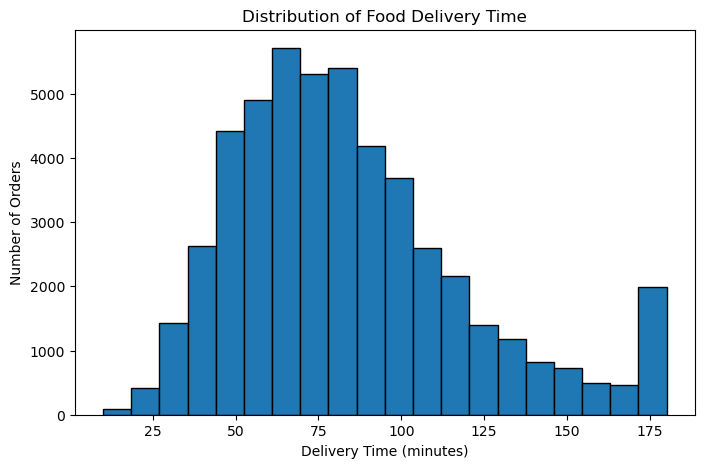

In [20]:
#Exploratory data analysis (EDA)-1. Histogram
import  matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.hist(df["Time_taken_min"], bins=20, edgecolor="black")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Number of Orders")
plt.title("Distribution of Food Delivery Time")

plt.show()


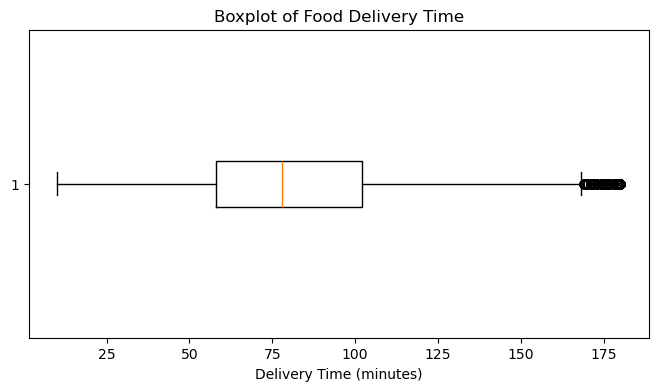

In [21]:
#boxplot for outliers
plt.figure(figsize=(8, 4))
plt.boxplot(
    df["Time_taken_min"],
    vert=False
)
plt.xlabel("Delivery Time (minutes)")
plt.title("Boxplot of Food Delivery Time")

plt.show()

In [22]:
df["Time_taken_min"].describe()

count    50000.000000
mean        83.868980
std         35.426899
min         10.000000
25%         58.000000
50%         78.000000
75%        102.000000
max        180.000000
Name: Time_taken_min, dtype: float64

In [23]:
Q1 = df["Time_taken_min"].quantile(0.25)
Q3 = df["Time_taken_min"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 58.0
Q3: 102.0
IQR: 44.0
Lower Bound: -8.0
Upper Bound: 168.0


In [24]:
outliers = df[
    (df["Time_taken_min"] < lower_bound) |
    (df["Time_taken_min"] > upper_bound)
]

print("Number of potential outliers:", len(outliers))

Number of potential outliers: 2153


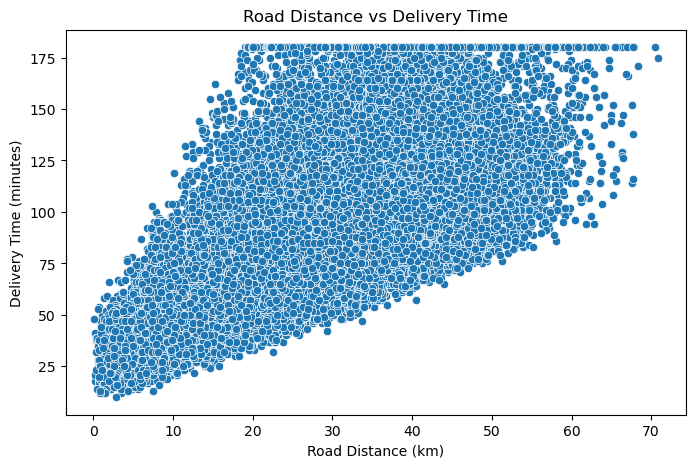

In [25]:
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Road_Distance_km",
    y="Time_taken_min"
)
plt.xlabel("Road Distance (km)")
plt.ylabel("Delivery Time (minutes)")
plt.title("Road Distance vs Delivery Time")

plt.show()

In [26]:
df["Road_Distance_km"].corr(df["Time_taken_min"])

0.7025917986038982

In [27]:
#Train/Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (40000, 23)
X_test: (10000, 23)
y_train: (40000,)
y_test: (10000,)


In [28]:
#Encode categorical data
from sklearn.preprocessing import OneHotEncoder
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)


Categorical columns:
Index(['Day_of_Week', 'Weather', 'Pickup_Zone', 'Dropoff_Zone', 'Vehicle_Type',
       'Cuisine_Type', 'Restaurant_Load', 'Delivery_Distance_Category',
       'Traffic_Level', 'Delivery_Priority'],
      dtype='object')

Numerical columns:
Index(['Order_Hour', 'Is_Weekend', 'Is_Festival', 'Rider_Experience_Years',
       'Rider_Rating', 'Restaurant_Rating', 'Order_Items',
       'Preparation_Time_Min', 'Road_Distance_km', 'Number_of_Signals',
       'Average_Speed_kmph', 'Month', 'Day'],
      dtype='object')


In [29]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

In [30]:
#Fit the encoder on training data
encoder.fit(X_train[categorical_cols])
X_train_encoded = encoder.transform(X_train[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])


In [31]:
#Convert encoded data into DataFrames
encoded_columns = encoder.get_feature_names_out(categorical_cols)

X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoded_columns,
    index=X_train.index
)

X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=encoded_columns,
    index=X_test.index
)

In [32]:
#Check the result
print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)
X_train_encoded.head()

Encoded training shape: (40000, 48)
Encoded testing shape: (10000, 48)


,Day_of_Week_Friday,Day_of_Week_Monday,Day_of_Week_Saturday,Day_of_Week_Sunday,Day_of_Week_Thursday,Day_of_Week_Tuesday,Day_of_Week_Wednesday,Weather_Clear,Weather_Cloudy,Weather_Fog,...,Delivery_Distance_Category_Long,Delivery_Distance_Category_Medium,Delivery_Distance_Category_Short,Traffic_Level_High,Traffic_Level_Low,Traffic_Level_Moderate,Traffic_Level_Severe,Delivery_Priority_Normal,Delivery_Priority_Priority,Delivery_Priority_VIP
39087,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
30893,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
45278,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
16398,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
13653,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [33]:
#Combine Numerical + Encoded Features
X_train_numeric = X_train[numerical_cols]
X_test_numeric = X_test[numerical_cols]
X_train_final = pd.concat(
    [X_train_numeric, X_train_encoded],
    axis=1
)

X_test_final = pd.concat(
    [X_test_numeric, X_test_encoded],
    axis=1
)

In [34]:
print("X_train_final:", X_train_final.shape)
print("X_test_final:", X_test_final.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train_final: (40000, 61)
X_test_final: (10000, 61)
y_train: (40000,)
y_test: (10000,)


In [35]:
print("Missing values in X_train:", X_train_final.isnull().sum().sum())
print("Missing values in X_test:", X_test_final.isnull().sum().sum())

Missing values in X_train: 0
Missing values in X_test: 0


In [36]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_final[numerical_cols] = scaler.fit_transform(
    X_train_final[numerical_cols]
)

In [37]:
X_test_final[numerical_cols] = scaler.transform(
    X_test_final[numerical_cols]
)

In [38]:
X_train_final.head()

,Order_Hour,Is_Weekend,Is_Festival,Rider_Experience_Years,Rider_Rating,Restaurant_Rating,Order_Items,Preparation_Time_Min,Road_Distance_km,Number_of_Signals,...,Delivery_Distance_Category_Long,Delivery_Distance_Category_Medium,Delivery_Distance_Category_Short,Traffic_Level_High,Traffic_Level_Low,Traffic_Level_Moderate,Traffic_Level_Severe,Delivery_Priority_Normal,Delivery_Priority_Priority,Delivery_Priority_VIP
39087,1.295549,1.592798,-0.227599,-0.116856,-1.529045,-1.337558,0.842407,-0.964016,-0.168838,-0.168516,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
30893,0.025274,-0.627826,-0.227599,0.634084,1.859327,-2.463271,-1.041715,0.710625,-0.492197,-0.861166,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
45278,-0.156194,-0.627826,-0.227599,0.941287,0.165141,-0.493273,0.214366,0.710625,-0.314666,-1.784700,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
16398,-0.519129,-0.627826,-0.227599,0.429282,1.181653,-0.493273,-0.413675,0.351773,-0.791779,-0.399399,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
13653,1.114081,-0.627826,-0.227599,0.565817,-0.512534,2.321009,-1.041715,0.710625,0.592799,-0.861166,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [39]:
print("Final training shape:", X_train_final.shape)
print("Final testing shape:", X_test_final.shape)

Final training shape: (40000, 61)
Final testing shape: (10000, 61)


In [40]:
#Train the Regression Model

from sklearn.linear_model import LinearRegression
reg_model = LinearRegression()
reg_model.fit(X_train_final, y_train)


LinearRegression()

In [41]:
y_pred = reg_model.predict(X_test_final)
print("Actual:", y_test.iloc[:10].values)
print("Predicted:", y_pred[:10])

Actual: [120 145  79  44  71  81  57  86 111  58]
Predicted: [129.515625 133.859375  82.359375  70.578125  74.484375  83.015625
  50.921875  88.484375 112.65625   59.203125]


In [42]:
#Evaluate the Regression Model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 6.373778125
MSE : 85.0624759765625
RMSE: 9.222932070473169
R²  : 0.9330339752170278


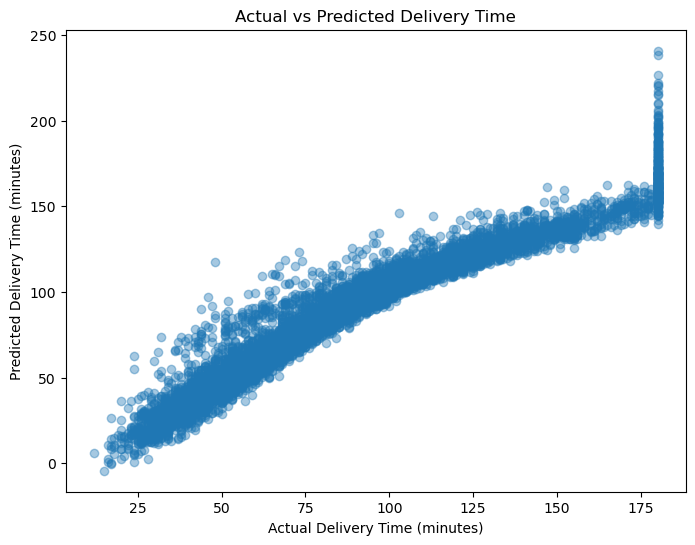

In [43]:
#Actual vs Predicted Visualization
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.4)

plt.xlabel("Actual Delivery Time (minutes)")
plt.ylabel("Predicted Delivery Time (minutes)")
plt.title("Actual vs Predicted Delivery Time")

plt.show()

In [44]:
#Train a Random Forest Regression Model
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [45]:
rf_model.fit(X_train_final, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [46]:
#Make Predictions with Random Forest

y_pred_rf = rf_model.predict(X_test_final)
print(y_pred_rf[:10])

[122.98 146.42  71.99  46.59  74.92  79.49  54.97  86.61 115.14  63.87]


In [47]:
#Evaluate Random Forest
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = mse_rf ** 0.5
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

MAE : 2.6355419999999996
MSE : 11.60428932
RMSE: 3.4065069088437205
R²  : 0.9908644426667522


In [48]:
#Compare the Two Models
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, mae_rf],
    "RMSE": [rmse, rmse_rf],
    "R2": [r2, r2_rf]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,6.373778,9.222932,0.933034
1,Random Forest,2.635542,3.406507,0.990864


In [49]:
#Create the Classification Target
df_ml["Time_taken_min"].describe()

count    50000.000000
mean        83.868980
std         35.426899
min         10.000000
25%         58.000000
50%         78.000000
75%        102.000000
max        180.000000
Name: Time_taken_min, dtype: float64

In [50]:
#Create the Classification Target
df_ml["Delivery_Speed"] = df_ml["Time_taken_min"].apply(
    lambda x: "Fast" if x <= 78 else "Slow"
)

In [51]:
df_ml["Delivery_Speed"].value_counts()

Delivery_Speed
Fast    25544
Slow    24456
Name: count, dtype: int64

In [52]:
#Prepare Classification Data
X_class = df_ml.drop(columns=["Time_taken_min", "Delivery_Speed"])
y_class = df_ml["Delivery_Speed"]
print("X shape:", X_class.shape)
print("y shape:", y_class.shape)

X shape: (50000, 23)
y shape: (50000,)


In [53]:
#Split Classification Data
from sklearn.model_selection import train_test_split

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)
print("Training:", Xc_train.shape, yc_train.shape)
print("Testing :", Xc_test.shape, yc_test.shape)

Training: (40000, 23) (40000,)
Testing : (10000, 23) (10000,)


In [54]:
#Encode Classification Features
categorical_cols_class = X_class.select_dtypes(include="object").columns
numerical_cols_class = X_class.select_dtypes(exclude="object").columns
from sklearn.preprocessing import OneHotEncoder

encoder_class = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

encoder_class.fit(Xc_train[categorical_cols_class])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [55]:
Xc_train_encoded = encoder_class.transform(Xc_train[categorical_cols_class])
Xc_test_encoded = encoder_class.transform(Xc_test[categorical_cols_class])

In [56]:
#Combine Numerical + Encoded Features
Xc_train_encoded = pd.DataFrame(
    Xc_train_encoded,
    columns=encoder_class.get_feature_names_out(categorical_cols_class),
    index=Xc_train.index
)
Xc_test_encoded = pd.DataFrame(
    Xc_test_encoded,
    columns=encoder_class.get_feature_names_out(categorical_cols_class),
    index=Xc_test.index
)
Xc_train_final = pd.concat(
    [Xc_train[numerical_cols_class], Xc_train_encoded],
    axis=1
)
Xc_test_final = pd.concat(
    [Xc_test[numerical_cols_class], Xc_test_encoded],
    axis=1
)

print("Training shape:", Xc_train_final.shape)
print("Testing shape:", Xc_test_final.shape)

Training shape: (40000, 61)
Testing shape: (10000, 61)


In [57]:
#Scale Numerical Features
from sklearn.preprocessing import StandardScaler

scaler_class = StandardScaler()

Xc_train_final[numerical_cols_class] = scaler_class.fit_transform(
    Xc_train_final[numerical_cols_class]
)

Xc_test_final[numerical_cols_class] = scaler_class.transform(
    Xc_test_final[numerical_cols_class]
)

In [58]:
print("Training shape:", Xc_train_final.shape)
print("Testing shape :", Xc_test_final.shape)


Training shape: (40000, 61)
Testing shape : (10000, 61)


In [59]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
model_class = LogisticRegression(max_iter=1000)
model_class.fit(Xc_train_final, yc_train)

LogisticRegression(max_iter=1000)

In [60]:
yc_pred = model_class.predict(Xc_test_final)
print("Predictions generated successfully!")
print(yc_pred[:10])

Predictions generated successfully!
['Fast' 'Fast' 'Slow' 'Fast' 'Fast' 'Fast' 'Fast' 'Fast' 'Fast' 'Fast']


In [61]:
#Evaluate the Classification Model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy = accuracy_score(yc_test, yc_pred)
print("Classification Accuracy:", accuracy)

Classification Accuracy: 0.9639


In [62]:
print("Classification Accuracy:", accuracy * 100, "%")

Classification Accuracy: 96.39 %


In [63]:
#Classification report
print(classification_report(yc_test, yc_pred))

              precision    recall  f1-score   support

        Fast       0.97      0.96      0.96      5109
        Slow       0.96      0.96      0.96      4891

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



In [64]:
#Confusion matrix
cm = confusion_matrix(yc_test, yc_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[4925  184]
 [ 177 4714]]


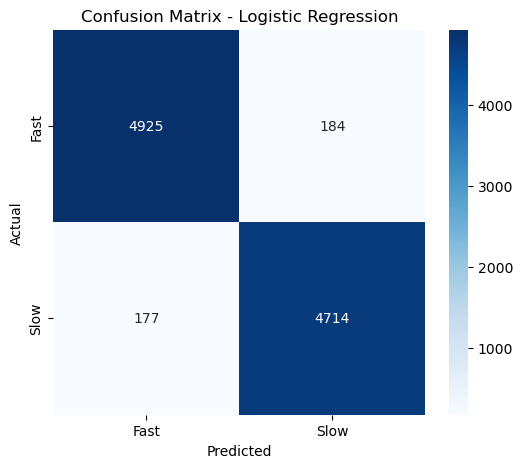

In [65]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model_class.classes_,
    yticklabels=model_class.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [66]:
print("Confusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("True Negative (TN):", tn)
print("False Positive (FP):", fp)
print("False Negative (FN):", fn)
print("True Positive (TP):", tp)

Confusion Matrix:
[[4925  184]
 [ 177 4714]]
True Negative (TN): 4925
False Positive (FP): 184
False Negative (FN): 177
True Positive (TP): 4714


In [67]:
#Calculate individual metrics
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)

print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

Precision: 0.9624336463862802
Recall: 0.9638110815784093
F1-Score: 0.9631218714884053


In [68]:
#Final Classification summary
print("Classification Model: Logistic Regression")
print("Target Variable: Delivery_Speed")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

Classification Model: Logistic Regression
Target Variable: Delivery_Speed
Accuracy: 0.9639
Precision: 0.9624336463862802
Recall: 0.9638110815784093
F1-Score: 0.9631218714884053


In [69]:
#Compare Regression and Classification
comparison = {
    "Model": [
        "Linear Regression",
        "Logistic Regression"
    ],
    "Task": [
        "Regression",
        "Classification"
    ],
    "Target": [
        "Delivery_Time_min",
        "Delivery_Speed"
    ]
}
comparison_df = pd.DataFrame(comparison)

print(comparison_df)

                 Model            Task             Target
0    Linear Regression      Regression  Delivery_Time_min
1  Logistic Regression  Classification     Delivery_Speed


In [70]:
#Saving classification predictions
classification_results = pd.DataFrame({
    "Actual_Delivery_Speed": yc_test.values,
    "Predicted_Delivery_Speed": yc_pred
})

print(classification_results.head(10))

  Actual_Delivery_Speed Predicted_Delivery_Speed
0                  Fast                     Fast
1                  Fast                     Fast
2                  Slow                     Slow
3                  Fast                     Fast
4                  Fast                     Fast
5                  Fast                     Fast
6                  Fast                     Fast
7                  Fast                     Fast
8                  Fast                     Fast
9                  Fast                     Fast


In [71]:
#Save result to csv
classification_results.to_csv(
    "classification_predictions.csv",
    index=False
)
print("Classification results saved successfully.")

Classification results saved successfully.


In [72]:
#Checking project file
import os
print(os.listdir())

['.ipynb_checkpoints', 'classification_predictions.csv', 'food_delivery_analysis.ipynb', 'model_comparison.csv']


In [73]:
#Regression result
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Regression Results")
print("------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Regression Results
------------------
MAE : 6.373778125
MSE : 85.0624759765625
RMSE: 9.222932070473169
R²  : 0.9330339752170278


In [74]:
#Classification Result
print("Classification Results")
print("----------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Classification Results
----------------------
Accuracy : 0.9639
Precision: 0.9624336463862802
Recall   : 0.9638110815784093
F1-Score : 0.9631218714884053


In [75]:
#final comparison
final_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Logistic Regression"],
    "Problem Type": ["Regression", "Classification"],
    "Target": ["Delivery_Time_min", "Delivery_Speed"],
    "Main Metric": ["R²", "Accuracy"],
    "Score": [r2, accuracy]
})

print(final_comparison)

                 Model    Problem Type             Target Main Metric  \
0    Linear Regression      Regression  Delivery_Time_min          R²   
1  Logistic Regression  Classification     Delivery_Speed    Accuracy   

      Score  
0  0.933034  
1  0.963900  


In [76]:
final_comparison

,Model,Problem Type,Target,Main Metric,Score
0,Linear Regression,Regression,Delivery_Time_min,R²,0.933034
1,Logistic Regression,Classification,Delivery_Speed,Accuracy,0.963900


In [77]:
#Saving Final comparison
final_comparison.to_csv(
    "model_comparison.csv",
    index=False
)

print("Final model comparison saved successfully.")

Final model comparison saved successfully.
